<a href="https://colab.research.google.com/github/NickLarsonUVA/DS3001-programming/blob/main/02_assignment_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 2: $k$ Nearest Neighbor

### Do any four. **Did Q1, Q2, Q3, Q6**

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
- Regression is used when the target variable is continuous (numerical). Ex: house prices, temperature, or age.
- Classification is used when the target variable is categorical (discrete classes). Ex: scam email recognition (spam/safe) or image recognition (cat/dog/mouse).
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
- A confusion matrix is a table that summarizes the performance of a classification model. It shows the counts of True Positives, True Negatives, False Positives, and False Negatives.
- It helps us understand how the model could be confused. For example, is it accurately predicting "Type A" but constantly mistaking "Type B" for "Type C"? It reveals specific error patterns that simple accuracy hides.
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
- Accuracy is the ratio of correct predictions to total predictions. True Positive + True Negative / Total (True/False Positives/Negatives)
- It might not be sufficient when the classes are imbalanced. If 99% of emails are not spam, a model that simply guesses "Not Spam" for everything has 99% accuracy but would be useless at actually detecting spam.
4. What does the root mean squared error quantify about a particular model?
- RMSE measures the average magnitude of the error. It quantifies how far off, on average, the model's predictions are from the actual values in the same units as the target variable. Lower values indicate better fit.
5. What are overfitting and underfitting?
- Overfitting: The model learns the training data too well, capturing noise and random fluctuations rather than the underlying pattern. If given new test data it will perform bad.
- Underfitting: The model is too simple to capture the underlying pattern of the data. It will perform bad on both training and testing data.
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
-  Splitting prevents "data leakage." If we choose $k$ based on training performance, we are just memorizing the data (overfitting, like the k=1 example in class with the majors). By evaluating a test set, we simulate how the model performs on unseen data, ensuring the chosen $k$ generalizes well to the real world.
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
- Class Label: Gives a definitive answer ("spam" or "not spam"). Strength: Simple to interpret. Weakness: Hides uncertainty; a 51% confidence prediction looks the same as a 99% confidence prediction.
- Probability: Gives the likelihood of each class ("51% chance its spam"). Strength: Allows for risk management (e.g., "Don't open unless 99% sure it's not"). Weakness: Requires setting a decision threshold.

In [ ]:
! git clone https://github.com/NickLarsonUVA/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 51 (delta 13), reused 6 (delta 6), pack-reused 32 (from 1)
Receiving objects: 100% (51/51), 132.11 KiB | 11.01 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Download complete
Extracting data files...
Data extracted


**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


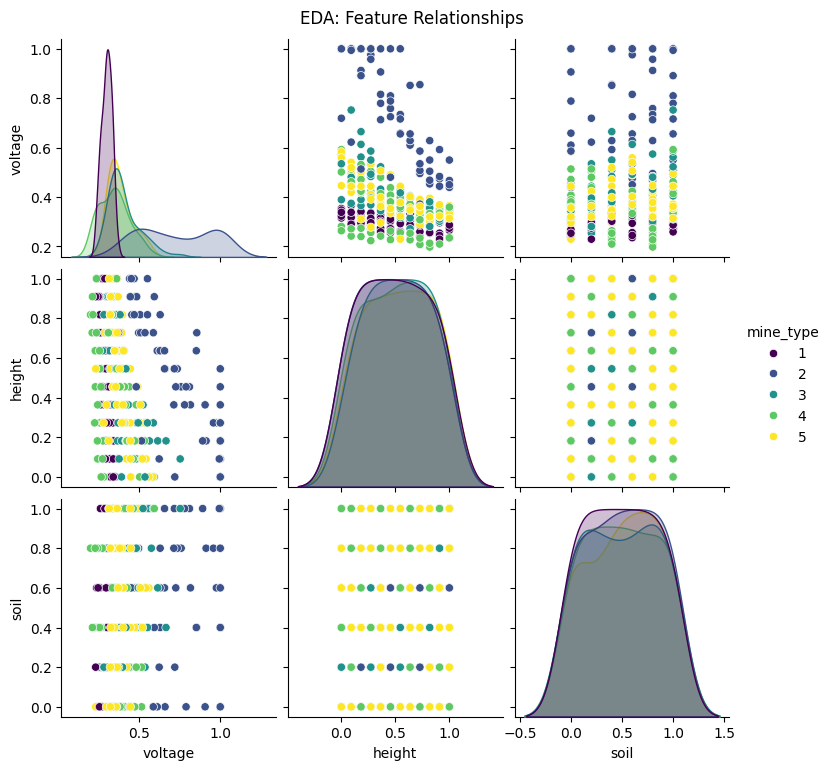

In [ ]:
#Q2 - 1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# load the data
df = pd.read_csv('/content/data/land_mines.csv')
print(df.head())

# summarize the target label
print(df['mine_type'].value_counts().sort_index())

# summarize features
print(df[['voltage', 'height', 'soil']].describe())

# visualizing Relationships
# using hue=target to see how classes separate, similar to the 'cars_env' example
sns.pairplot(df, hue='mine_type', palette='viridis')
plt.suptitle("EDA: Feature Relationships", y=1.02)
plt.show()

In [ ]:
#Q2 - 2
# 1. Select Data
y = df['mine_type'] # target
ctrl_list = ['voltage', 'height', 'soil'] # features
X = df.loc[:, ctrl_list]

# normalize (Min-Max Scaling)
# notebook suggests transforming data so values lie between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
u = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# train-test split (50/50 as requested in Q2)
# notebook emphasizes using a fixed random_state for replication
u_train, u_test, y_train, y_test = train_test_split(
    u, y,
    test_size=0.5,
    random_state=42,
    stratify=y # good practice for classification to maintain class proportions
)
print(f"Training shape: {u_train.shape}")

Training shape: (169, 3)


k=3: Test Accuracy = 0.385
k=5: Test Accuracy = 0.355
k=7: Test Accuracy = 0.343
k=9: Test Accuracy = 0.367
k=11: Test Accuracy = 0.379
k=13: Test Accuracy = 0.373
k=15: Test Accuracy = 0.385
k=17: Test Accuracy = 0.373
k=19: Test Accuracy = 0.361
k=21: Test Accuracy = 0.361
k=23: Test Accuracy = 0.367
k=25: Test Accuracy = 0.373
k=27: Test Accuracy = 0.385
k=29: Test Accuracy = 0.414


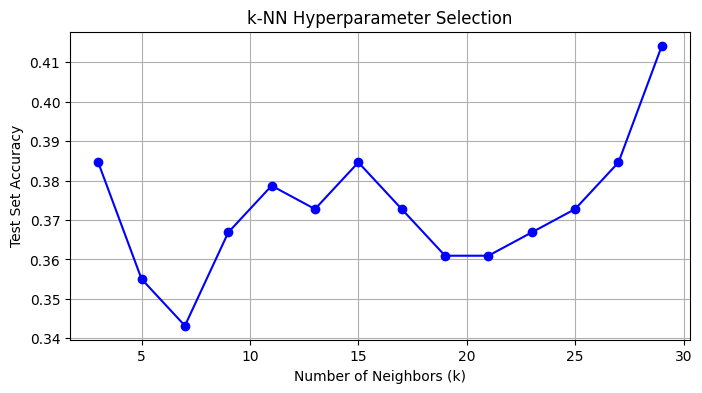


Selected optimal k = 29 with Accuracy = 41.42%


In [ ]:
#Q2 - 3
# define a grid of k values (hyperparameter tuning)
# use odd numbers to break ties in voting.
k_grid = [(2*k+1) for k in range(1, 15)] #checks within a range

test_accuracies = []

for k in k_grid:
    # create model instance
    model = KNeighborsClassifier(n_neighbors=k)

    # fit on the SCALED training data (u_train from above)
    model.fit(u_train, y_train)

    # evaluate on the SCALED test data (u_test)
    # model.score returns the accuracy
    acc = model.score(u_test, y_test)
    test_accuracies.append(acc)

    print(f"k={k}: Test Accuracy = {acc:.3f}")

# show perforamnce
plt.figure(figsize=(8, 4))
plt.plot(k_grid, test_accuracies, marker='o', linestyle='-', color='b')
plt.title('k-NN Hyperparameter Selection')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Set Accuracy')
plt.grid(True)
plt.show()

# select the best k
best_idx = np.argmax(test_accuracies)
best_k = k_grid[best_idx]
print(f"\nSelected optimal k = {best_k} with Accuracy = {test_accuracies[best_idx]:.2%}")

In [ ]:
#Q2 - 4
# rebuild the model with the optimal k found above
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(u_train, y_train)

# predict on the test set
y_hat = best_model.predict(u_test)

# print confusion table (Crosstab)
print(f"Confusion Table for Best Model (k={best_k}):\n")

# pd.crosstab(Actual, Predicted)
conf_matrix = pd.crosstab(y_test, y_hat,
                          rownames=['Actual Mine Type'],
                          colnames=['Predicted Mine Type'])

print(conf_matrix)

Confusion Table for Best Model (k=29):

Predicted Mine Type   1   2   3  4  5
Actual Mine Type                     
1                    21   0   4  8  3
2                     3  24   4  0  4
3                     9   0  12  3  9
4                    11   0  13  5  4
5                     6   1  10  7  8


In [ ]:
#Q2 - 4 continued (rationale)
# The model achieves an overall accuracy of approximately 41.4% on the test set.
# Performance is strongest for Mine Type 2, where the model correctly identifies
# 24 out of 35 instances with very high precision. Conversely, the model struggles
# significantly with Mine Types 4 and 5, correctly predicting only a small fraction
# of cases and frequently confusing them with Types 1 and 3.

In [ ]:
#Q2 - 5
# I would advise using this model primarily as a reliable "Type 2 Detector."
# It correctly identifies that specific mine type with 96% precision while
# rarely generating false alarms. However, because the model frequently confuses
# Types 3, 4, and 5 with one another, any prediction other than Type 2 should be
# treated with extreme caution and verified manually as if the type were unknown.
# In practice, this allows the disposal team to rapidly deploy specific equipment
#for Type 2 mines while maintaining standard high-alert protocols for all other signals.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [ ]:
#Q3 - 1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load
df_cars = pd.read_csv('/content/data/USA_cars_datasets.csv')

# keep variables: price, year, mileage
df_cars = df_cars[['price', 'year', 'mileage']]

# check NAs
print(df_cars.isna().sum())

# drop rows with NAs
df_cars = df_cars.dropna()
print(f"\nDimensions after dropping NAs: {df_cars.shape}")

print(df_cars.head())

price      0
year       0
mileage    0
dtype: int64

Dimensions after dropping NAs: (2499, 3)
   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654


In [ ]:
#Q3 - 2/3
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# target and features
y = df_cars['price']
X = df_cars[['year', 'mileage']]

# MaxMin normalize Features
scaler = MinMaxScaler()
u = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# split the sample (80% Training, 20% Test)
# random_state=42 ensures we get the same split every time
u_train, u_test, y_train, y_test = train_test_split(
    u, y,
    test_size=0.2,
    random_state=42
  )

print(f"Training set size: {u_train.shape[0]}")
print(f"Test set size: {u_test.shape[0]}")

Training set size: 1999
Test set size: 500


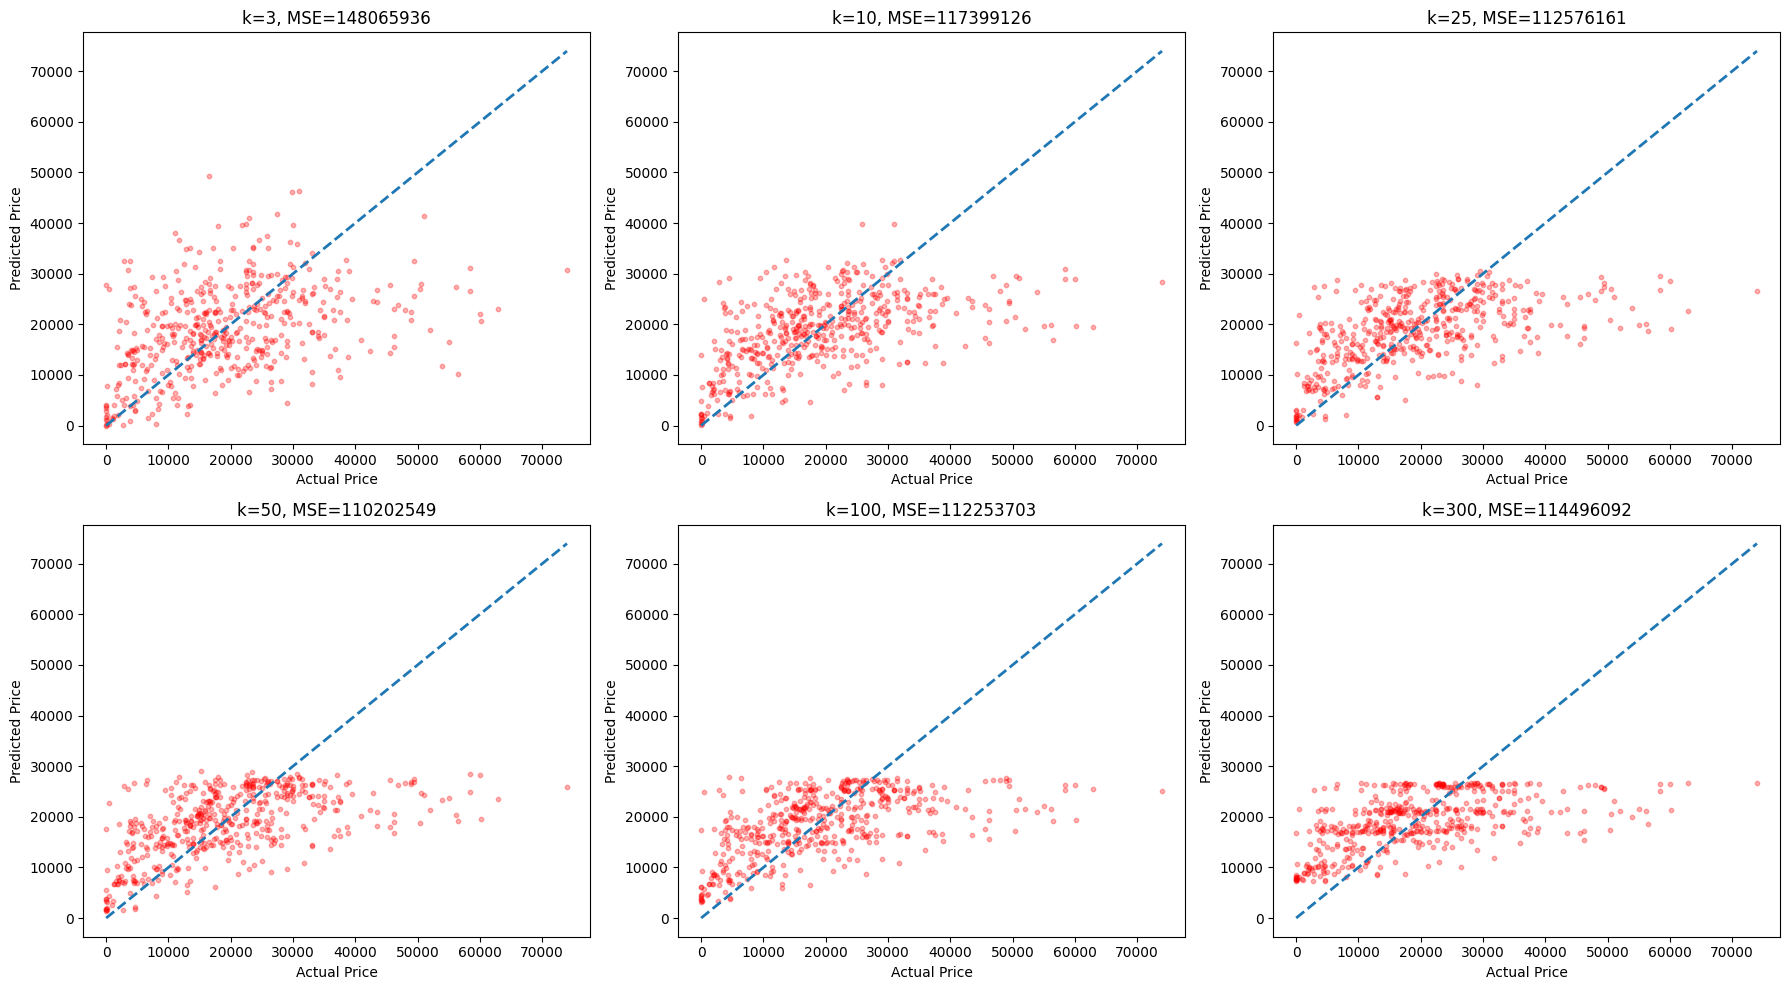

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# k values
k_values = [3, 10, 25, 50, 100, 300]

# plot grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flattens the 2x3 grid so can loop over it easily

for i, k in enumerate(k_values):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(u_train, y_train)

    # predict on Test Set
    y_pred = model.predict(u_test)

    # compute errors
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # plot predicted vs actual
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.3, color='red', s=10)
    max_val = max(y_test.max(), y_pred.max())
    min_val = min(y_test.min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], '--', lw=2)

    ax.set_title(f'k={k}, MSE={mse:.0f}')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

In [ ]:
#Q3 - 5
# The optimal number of neighbors for these data is k=50. This value produces
# the lowest Mean Squared Error (110,202,549) on the test set, indicating
# the best balance between bias and variance.

In [ ]:
#Q3 - 6
# At low values like k=3, the high MSE indicates overfitting, where the model
# captures noise rather than the true trend. As k increases beyond 50 to 300,
# the MSE rises again, indicating underfitting because the model smooths over
# too many neighbors and fails to capture local price variations.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [ ]:
# Q6 - 1
df_air = pd.read_csv("/content/data/airbnb_hw.csv")

# filter
df_air = df_air.loc[:, ['Review Scores Rating', 'Price', 'Beds']]

print(df_air.head())

   Review Scores Rating Price  Beds
0                   NaN   145   1.0
1                   NaN    37   1.0
2                   NaN    28   1.0
3                   NaN   199   3.0
4                  96.0   549   3.0


In [ ]:
# Q6 - 2
# boolean mask for missing reviews
# .isnull() returns true if the value is NaN, false otherwise
missing_mask = df_air['Review Scores Rating'].isnull()

# use .loc to select the subset of the dataframe with missing values
df_missing = df_air.loc[missing_mask]

# verify the separation
print(f"Number of observations to impute (df_missing): {len(df_missing)}")
print(df_missing.head())

Number of observations to impute (df_missing): 8323
    Review Scores Rating Price  Beds
0                    NaN   145   1.0
1                    NaN    37   1.0
2                    NaN    28   1.0
3                    NaN   199   3.0
13                   NaN    68   1.0


In [ ]:
# Q6 - 3
# get rid of missing
# axis=0 means drop rows, how='any' means if any value is missing
df_air = df_air.dropna(axis=0, how='any')

# see if it worked
print(f"Number of complete observations remaining (df): {len(df)}")
print(df.head())

Number of complete observations remaining (df): 338
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1


In [ ]:
# need to remove stuff from prices
df_air['Price'] = df_air['Price'].astype(str).str.replace(',', '').astype(float)

k     | SSE            
-------------------------
3     | 487159.56      
5     | 404900.76      
7     | 377401.65      
9     | 350738.38      
11    | 344369.29      
-------------------------
Optimal k: 97
Minimum SSE: 315559.91


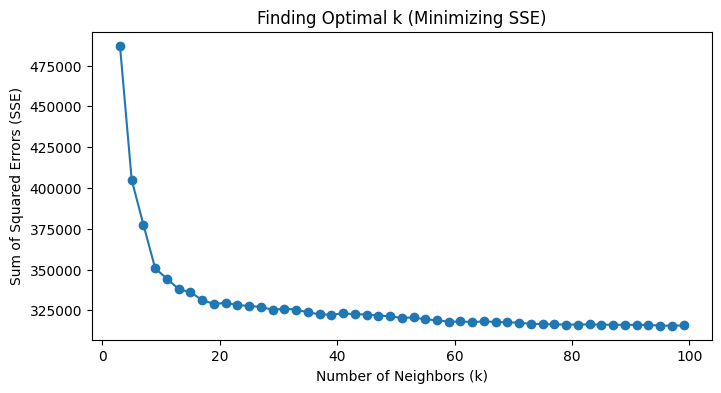

In [ ]:
# Q6 - 4
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

# variables
y = df_air['Review Scores Rating']
X = df_air[['Price', 'Beds']]

# normalize
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# iterate to find optimal k (Minimizing SSE)
k_values = [2*k+1 for k in range(1, 50)] # Odd numbers
sse_values = []

print(f"{'k':<5} | {'SSE':<15}")
print("-" * 25)

for k in k_values:
    # train
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    # predict
    preds = model.predict(X_test)

    # SSE = Sum((Actual - Predicted)^2)
    sse = np.sum((y_test - preds)**2)
    sse_values.append(sse)

    # print to verify
    if k < 12:
        print(f"{k:<5} | {sse:<15.2f}")

# find optimal
best_k_idx = np.argmin(sse_values)
best_k = k_values[best_k_idx]
min_sse = sse_values[best_k_idx]

print("-" * 25)
print(f"Optimal k: {best_k}")
print(f"Minimum SSE: {min_sse:.2f}")

# SSE plot
plt.figure(figsize=(8, 4))
plt.plot(k_values, sse_values, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Finding Optimal k (Minimizing SSE)')
plt.show()

In [ ]:
# the best k is 97. It minimizes SSE. Smooths out the noise most

In [ ]:
#Q6 - 5
# clean the df_missing
df_missing['Price'] = df_missing['Price'].astype(str).str.replace(',', '').astype(float)
df_missing = df_missing.dropna(subset=['Price', 'Beds'])

X_missing = df_missing[['Price', 'Beds']]
# normalize missing data
X_missing_scaled = scaler.transform(X_missing)

# retrain with best k
best_k = 97
final_model = KNeighborsRegressor(n_neighbors=best_k)

# Fit on the full complete dataset (X_scaled and y from previous)
final_model.fit(X_scaled, y)

# predict
imputed_ratings = final_model.predict(X_missing_scaled)

# store
df_missing['Predicted Rating'] = imputed_ratings

print("Prediction complete.")
print(f"First 5 imputed ratings:\n{df_missing[['Price', 'Beds', 'Predicted Rating']].head()}")

Prediction complete.
First 5 imputed ratings:
    Price  Beds  Predicted Rating
0   145.0   1.0         94.185567
1    37.0   1.0         88.381443
2    28.0   1.0         86.494845
3   199.0   3.0         88.226804
13   68.0   1.0         90.835052


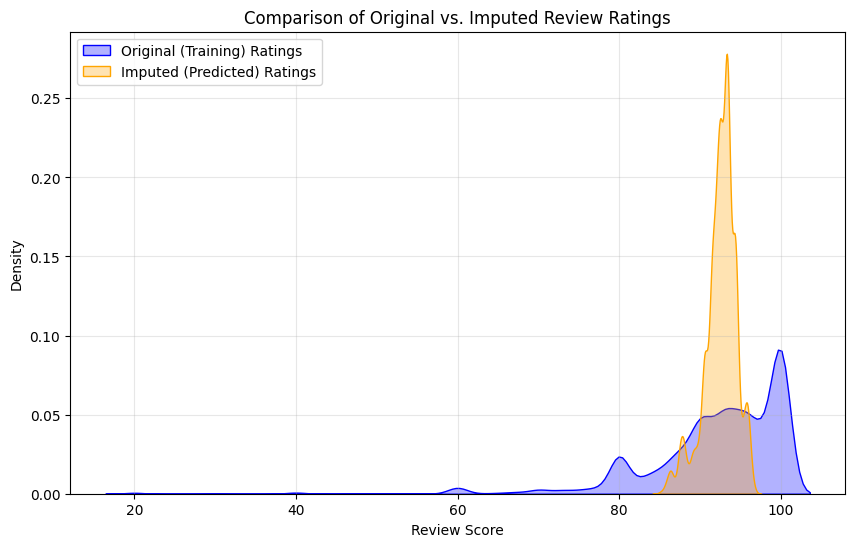

In [ ]:
#Q6 - 6
# size
plt.figure(figsize=(10, 6))

# original
sns.kdeplot(y, label='Original (Training) Ratings', fill=True, color='blue', alpha=0.3)

# predicted
sns.kdeplot(df_missing['Predicted Rating'], label='Imputed (Predicted) Ratings', fill=True, color='orange', alpha=0.3)

# labels / title
plt.title('Comparison of Original vs. Imputed Review Ratings')
plt.xlabel('Review Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Q6 - 6 continued
# The training and predicted ratings don't look very similar at all.
# The blue curve (actual ratings) has a realistic shape with clear peaks at 80
# and 100, showing that people often give perfect or good scores, while the
# orange curve (predictions) is just a single, narrow spike around the low 90s.
# This happened because using so many neighbors (k=97) averaged everything out
# too much, so the model missed the high and low extremes and just guessed the
# average for everyone.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)